In [1]:
import sys
sys.path.insert(0, "/home/syedkazim/sciebo - Kazim, Syed Muhammad (u491036@uni-siegen.de)@uni-siegen.sciebo.de/Lab/Projects/2025_[Ongoing]_Speckle_Flow_Networks_QIP/coded_wfs_sim")

from coded_wfs_sim import geometry
from coded_wfs_sim import propagator
from coded_wfs_sim import visualization
from coded_wfs_sim import utils

import numpy as np
from tifffile import tifffile
from matplotlib import pyplot as plt
import cv2

import torch
from torch import nn, Tensor
from torchvision.models.optical_flow import raft_large
from torchvision.models.optical_flow import Raft_Large_Weights
import torchvision.transforms.functional as F
from torchvision.utils import flow_to_image
from torch.utils.tensorboard import SummaryWriter

from scipy.ndimage import gaussian_filter, median_filter
from scipy.signal import correlate2d, convolve2d, tukey
from scipy.interpolate import RegularGridInterpolator
import scipy

import numpy as np
import matplotlib.pyplot as plt
from zernike import RZern

from typing import Optional, Union

import cws_module

qt.qpa.plugin: Could not find the Qt platform plugin "wayland" in ""


# Networks training on HEK data

# Test datasets and figures and testing
1. test synthetic bead stacks
2. test synthetic HEK cells

In [ ]:
def generate_ref_obj_wavefields_from_vol_v2(RI_distribution, phase_mask, dist_m_im, dist_m_im_var, 
                                            wl, n_background, spatial_resolution, spatial_support, 
                                            mag=60, focal_plan_var=2e-6, padding=256, NA=0.85,
                                            partial_coherence_smoothing=0.1, im_to_ob_space_scale=30):
    
    k = 2*np.pi/wl
    # im_to_ob_space_scale = 30
    mag2 = int(mag/im_to_ob_space_scale)
    
    
    # prop though volume and then to focal plane
    output_field = propagator.propagate_beam_2(np.ones_like(RI_distribution[..., 1]), RI_distribution, n_background, wl, spatial_resolution)
    output_field = propagator.propagate(output_field, wl/n_background, spatial_resolution, spatial_support[2]/2, padding=padding, direction='backward')
    
    # for focal stacks
    if focal_plan_var > 0:
        output_field = propagator.propagate(output_field, wl, spatial_resolution, np.abs(focal_plan_var), padding=padding, direction='forward')
    else:
        output_field = propagator.propagate(output_field, wl, spatial_resolution, np.abs(focal_plan_var), padding=padding, direction='backward')

    # NA based low-pass filtering
    output_field = utils.low_pass_filter_NA(output_field, wl, spatial_resolution, NA)
    
    # approx partial coherence
    output_field = gaussian_filter(output_field, partial_coherence_smoothing, truncate=10)
    
    # magnification
    dx, dy = output_field.shape

    # output_field_b_sc_mag = cv2.resize(output_field_b_sc.real[int(dx/2 - dx/(2*mag2)):int(dx/2 + dx/(2*mag2)), int(dy/2 - dy/(2*mag2)):int(dy/2 + dy/(2*mag2))], 
                                    # (dx, dy), interpolation = cv2.INTER_CUBIC) + 1j*cv2.resize(output_field_b_sc.imag[int(dx/2 - dx/(2*mag2)):int(dx/2 + dx/(2*mag2)), int(dy/2 - dy/(2*mag2)):int(dy/2 + dy/(2*mag2))], (dx, dy), interpolation = cv2.INTER_CUBIC)
    output_field = cv2.resize(output_field.real, (dx*mag2, dy*mag2), interpolation = cv2.INTER_CUBIC) + 1j*cv2.resize(output_field.imag, (dx*mag2, dy*mag2), interpolation = cv2.INTER_CUBIC)
    
    # prop to phase mask plane
    output_field = propagator.propagate(output_field, wl, np.array(spatial_resolution)*im_to_ob_space_scale, dist_m_im + dist_m_im_var, padding=padding, direction='backward')
    # visualization.visualize_complex_field(output_field, np.array(spatial_support)*im_to_ob_space_scale)
    
    # calculate ground truth flow
    flow_y, flow_x = utils.grad_optr(np.angle(output_field))
    gt_flow_y = (np.remainder(flow_y + np.pi, 2*np.pi) - np.pi)/((spatial_resolution[0]*im_to_ob_space_scale)**2)/k*(dist_m_im + dist_m_im_var)
    gt_flow_x = (np.remainder(flow_x + np.pi, 2*np.pi) - np.pi)/(spatial_resolution[1]*im_to_ob_space_scale)**2/k*(dist_m_im + dist_m_im_var)

    # mask modulation and prop to image plane [1:-1, 1:-1]
    output_field_sensor = propagator.propagate(output_field*phase_mask, wl, np.array(spatial_resolution)*im_to_ob_space_scale, dist_m_im + dist_m_im_var, padding=padding, direction='forward')
    # output_field_sensor = propagator.propagate(output_field*phase_mask, wl, np.array(spatial_resolution)*30, dist_m_im + dist_m_im_var, padding=padding, direction='forward')
    
    # mask modulation and prop to image plane
    ref_field_sensor = propagator.propagate(phase_mask, wl, np.array(spatial_resolution)*im_to_ob_space_scale, dist_m_im + dist_m_im_var, padding=padding, direction='forward')
    # ref_field_sensor = propagator.propagate(phase_mask, wl, np.array(spatial_resolution)*30, dist_m_im + dist_m_im_var, padding=padding, direction='forward')
    
    return ref_field_sensor[5:-5, 5:-5], output_field_sensor[5:-5, 5:-5], [-1*gt_flow_x[5:-5, 5:-5], -1*gt_flow_y[5:-5, 5:-5]]


def generate_cell(HEK_params, cart, meshgrid, mean_var=5e-4, std_var=5, ran_crop=True, ran_flip=True, ran_rotate=True):
    
    temp_coeffs = std_var*HEK_params[1]*np.random.rand(861) + HEK_params[0] + mean_var*np.random.rand(861)
    gen_cell = np.where(cart.eval_grid(temp_coeffs, matrix=True) < 0.005, 0., cart.eval_grid(temp_coeffs, matrix=True))
    gen_cell = np.where(meshgrid[0]**2 + meshgrid[1]**2 > 0.5, 0., gen_cell)
    
    if ran_crop:
        # random crop -> displace the cell and change the size of the cell
        ch = 50 + np.random.randint(-50, 100)
        cv = -50 + np.random.randint(-100, 50)
        
        gen_cell = gen_cell[ch:cv, ch:cv]
        
        crop_odd = (ch -1*cv) % 2 == 1
        pad_by = np.ceil((ch -1*cv)/2).astype(int)
        if crop_odd:
            gen_cell = gen_cell[:-1, :-1]
            
        gen_cell = np.pad(gen_cell, pad_by)
        
    if ran_flip:
        gen_cell = np.flip(gen_cell, axis=np.random.randint(0, 2))
        gen_cell = np.flip(gen_cell, axis=np.random.randint(0, 2))
        
    if ran_rotate:
        gen_cell = scipy.ndimage.rotate(gen_cell, np.random.randint(-45, 45), reshape=False)
    
    return gen_cell


def create_phase_mask(height_range, grid_shape, tile_size, wl, RI_pm, smoothing=5, padding=0):
    h_pm = wl/np.random.randint(height_range[0], height_range[1])
    hmap_pm = geometry.initialize_hmap_uniform_sampling(grid_shape[:2], tile_size, h_pm)
    hmap_pm = np.pad(hmap_pm, padding, 'edge')
    opd_pm = gaussian_filter(hmap_pm*RI_pm + (hmap_pm.max() - hmap_pm)*1., smoothing) # phase mask in air
    
    return np.exp(1j*(2*np.pi/wl)*opd_pm)


# model
def init_model_RAFT(model, device='cuda', checkpoint=None):
    
    if checkpoint == None:
        print('Loading models with pretrained weights')
        weights = Raft_Large_Weights.DEFAULT.get_state_dict()
        weights['feature_encoder.convnormrelu.0.weight'] = torch.mean(weights['feature_encoder.convnormrelu.0.weight'], dim=1).unsqueeze(1)
        weights['context_encoder.convnormrelu.0.weight'] = torch.mean(weights['context_encoder.convnormrelu.0.weight'], dim=1).unsqueeze(1)
    else:
        print(f'Loading models with checkpoint: {checkpoint}')
        weights = torch.load(checkpoint, map_location=torch.device(device))
    
    # model = raft_large(progress=False)
    model.feature_encoder.convnormrelu[0] = torch.nn.Conv2d(1, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3))
    model.context_encoder.convnormrelu[0] = torch.nn.Conv2d(1, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3))
    
    model.load_state_dict(weights)
    
    return model.to(device)
    

def RAFT_loss(predictions, target, device='cuda'):
	loss_fn = torch.nn.L1Loss()
	N = len(predictions)
	
	w = torch.pow(torch.tensor(0.8), N-torch.tensor(range(1, N+1))).to(device)
	loss_n = torch.sum(torch.abs(torch.stack(predictions, dim=0) - target.unsqueeze(0).repeat(12, 1, 1, 1, 1)), dim=[1, 2, 3, 4])
	
	return torch.sum(w*loss_n).squeeze()


def plot(imgs, **imshow_kwargs):
    if not isinstance(imgs[0], list):
        # Make a 2d grid even if there's just 1 row
        imgs = [imgs]

    num_rows = len(imgs)
    num_cols = len(imgs[0])
    _, axs = plt.subplots(nrows=num_rows, ncols=num_cols, squeeze=False)
    for row_idx, row in enumerate(imgs):
        for col_idx, img in enumerate(row):
            ax = axs[row_idx, col_idx]
            img = F.to_pil_image(img.to("cpu"))
            ax.imshow(np.asarray(img), **imshow_kwargs)
            ax.set(xticklabels=[], yticklabels=[], xticks=[], yticks=[])

    plt.tight_layout()

# Synthetic beads test dataset and Figure

In [34]:
# Grid and propagation parameters setup
wl = 640e-9
spatial_resolution = [100e-9, 100e-9, 100e-9] # dx, dy, dz
grid_shape = [500, 500, 200] # x=0->, y=0->, z=0->
n_background = 1.518 # immersion medium RI
spatial_support = [spatial_resolution[i]*grid_shape[i] for i in range(3)]

c_m = [25e-6, 25e-6, 10e-6]
c_v = [5e-6, 5e-6, 2e-6]

rad_params = [3, 8, 1e-6]
RI_params = [1.5, 0.07]

pad = 256
NA = 0.85
mag = 60
im_to_ob_space_scale = 30
mag2 = int(mag/im_to_ob_space_scale)
dist_m_im = 1.43e-3
partial_coherence_smoothing = 0.001

side_length = 10e-6
tile_size = int(side_length/(spatial_resolution[0]*im_to_ob_space_scale))
RI_pm = 1.46
pm_smoothing = 3

int_gaus_noise = 2e-3

geom = geometry.Geometry(grid_shape, spatial_resolution, n_background)

Coordiante system with size: 
 
              X = [0, 5.00e-05], Res_X = 1e-07
              Y = [0, 5.00e-05], Res_Y = 1e-07
              Z = [0, 2.00e-05], Res_Z = 1e-07
              Immersion RI: 1.518
      


In [4]:
# ref_imgs.append(img_ref/torch.mean(img_ref))
# obj_imgs.append(img_obj/torch.mean(img_obj))    
# gt_flows.append([gt_flow[0][::2, ::2], gt_flow[1][::2, ::2]])

# if args.data_save == 'yes':
#     if not os.path.exists(f'runs/{date}/data/obj'):
#         os.makedirs(f'runs/{date}/data/obj')
#     if not os.path.exists(f'runs/{date}/data/ref'):
#         os.makedirs(f'runs/{date}/data/ref')
            
#     if not os.path.exists(f'runs/{date}/data/ground_truth'):
#         os.makedirs(f'runs/{date}/data/ground_truth')
        
#     tifffile.imwrite(f'runs/{date}/data/obj/{it1}_{it2}.tiff', utils.normalization(img_obj))
#     tifffile.imwrite(f'runs/{date}/data/ref/{it1}_{it2}.tiff', utils.normalization(img_ref))
#     tifffile.imwrite(f'runs/{date}/data/ground_truth/{it1}_{it2}_0.tiff', utils.normalization(gt_flow[0][::2, ::2]))
#     tifffile.imwrite(f'runs/{date}/data/ground_truth/{it1}_{it2}_1.tiff', utils.normalization(gt_flow[1][::2, ::2]))

In [81]:
np.random.seed(0)

phase_mask = create_phase_mask([2, 4], np.array(grid_shape)*mag2, tile_size, wl, RI_pm, 
                        smoothing=pm_smoothing, padding=1)[:-1, :-1]

    # generate data 3D tensor
num_elements = np.random.randint(1, 6)

RI_distribution_1 = geometry.generate_bead_data(geom, c_m, c_v, rad_params, RI_params, num_elements).get_grid()
geom.reset_grid()

# generate NN input and label
dist_m_im_var = np.random.rand()*2e-3 - 0.5e-3
f_plane_delta = np.random.randn()*4e-6

ref_wave, obj_wave, gt_flow = generate_ref_obj_wavefields_from_vol_v2_grad_median(RI_distribution_1, phase_mask, dist_m_im, dist_m_im_var, 
                                wl, n_background, spatial_resolution, spatial_support, 
                                mag=mag, focal_plan_var=f_plane_delta, padding=pad, NA=NA,
                                partial_coherence_smoothing=partial_coherence_smoothing, 
                                im_to_ob_space_scale=im_to_ob_space_scale)

img_ref = torch.clamp(torch.abs(torch.tensor(ref_wave[::2, ::2]))**2 + 0*int_gaus_noise*torch.randn(495, 495), min=0).float()
img_obj = torch.clamp(torch.abs(torch.tensor(obj_wave[::2, ::2]))**2 + 0*int_gaus_noise*torch.randn(495, 495), min=0).float()

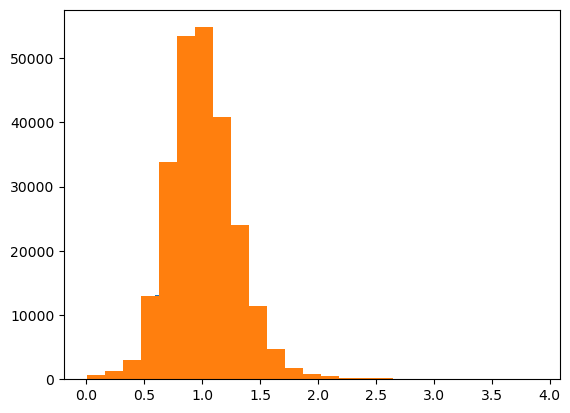

In [70]:
plt.hist(img_ref.ravel(), bins=25)
plt.hist(img_obj.ravel(), bins=25);

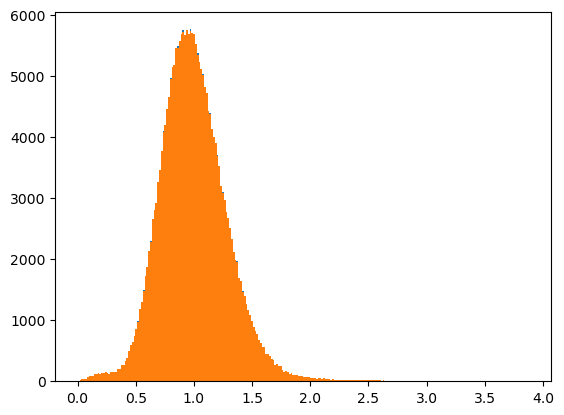

In [60]:
img_obj2 = np.array(img_obj*10e3, dtype=np.uint16)

plt.hist(img_obj.ravel()/torch.mean(img_obj), bins=250)
plt.hist(img_obj2.ravel()/np.mean(img_obj2), bins=250);

65535


3206.6035916868095

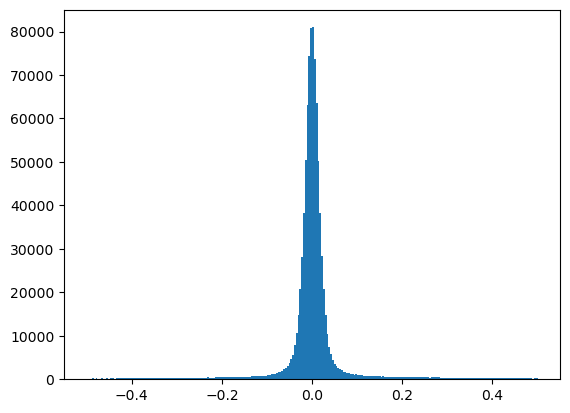

In [82]:
plt.hist(gt_flow[0].ravel(), bins=250, range=(-0.5, 0.5));

gt_flow_x2 = np.array((gt_flow[0] + 3)*1000, dtype=np.uint16)

print(gt_flow_x2.max())
plt.hist((gt_flow_x2/1000 - 10).ravel(), bins=250, range=(-0.5, 0.5));

np.linalg.norm((gt_flow_x2/1000 - 3) - gt_flow[0])

In [44]:
np.random.seed(0)

for it1 in range(1500):
    
    # generate phase mask
    phase_mask = create_phase_mask([2, 4], np.array(grid_shape)*mag2, tile_size, wl, RI_pm, 
                            smoothing=pm_smoothing, padding=1)[:-1, :-1]
    
    # s_crop_dims = np.random.randint(400, high=475, size=2)
    for it2 in range(3):

    # generate data 3D tensor
        num_elements = np.random.randint(1, 6)

        RI_distribution_1 = geometry.generate_bead_data(geom, c_m, c_v, rad_params, RI_params, num_elements).get_grid()
        geom.reset_grid()

        # generate NN input and label
        dist_m_im_var = np.random.rand()*2e-3 - 0.5e-3
        f_plane_delta = np.random.randn()*4e-6

        ref_wave, obj_wave, gt_flow = generate_ref_obj_wavefields_from_vol_v2(RI_distribution_1, phase_mask, dist_m_im, dist_m_im_var, 
                                        wl, n_background, spatial_resolution, spatial_support, 
                                        mag=mag, focal_plan_var=f_plane_delta, padding=pad, NA=NA,
                                        partial_coherence_smoothing=partial_coherence_smoothing, 
                                        im_to_ob_space_scale=im_to_ob_space_scale)

        img_ref = torch.clamp(torch.abs(torch.tensor(ref_wave[::2, ::2]))**2 + 0*int_gaus_noise*torch.randn(495, 495), min=0).float()
        img_obj = torch.clamp(torch.abs(torch.tensor(obj_wave[::2, ::2]))**2 + 0*int_gaus_noise*torch.randn(495, 495), min=0).float()
        
        img_ref2 = np.array(img_ref*10e3, dtype=np.uint16)
        img_obj2 = np.array(img_obj*10e3, dtype=np.uint16)
        
        gt_flow_02 = np.array((gt_flow[0][::2, ::2] + 3)*10000, dtype=np.uint16)
        gt_flow_12 = np.array((gt_flow[1][::2, ::2] + 3)*10000, dtype=np.uint16)
        
        tifffile.imwrite(f'data/microbeads_training_seed0/ref/{it1}_{it2}.tiff', img_ref2)
        tifffile.imwrite(f'data/microbeads_training_seed0/obj/{it1}_{it2}.tiff', img_obj2)
        
        tifffile.imwrite(f'data/microbeads_training_seed0/grad/{it1}_{it2}_0.tiff', gt_flow_02)
        tifffile.imwrite(f'data/microbeads_training_seed0/grad/{it1}_{it2}_1.tiff', gt_flow_12)
        

In [54]:
def generate_ref_obj_wavefields_from_vol_v2_grad_median(RI_distribution, phase_mask, dist_m_im, dist_m_im_var, 
                                            wl, n_background, spatial_resolution, spatial_support, 
                                            mag=60, focal_plan_var=2e-6, padding=256, NA=0.85,
                                            partial_coherence_smoothing=0.1, im_to_ob_space_scale=30):
    
    k = 2*np.pi/wl
    # im_to_ob_space_scale = 30
    mag2 = int(mag/im_to_ob_space_scale)
    
    
    # prop though volume and then to focal plane
    output_field = propagator.propagate_beam_2(np.ones_like(RI_distribution[..., 1]), RI_distribution, n_background, wl, spatial_resolution)
    output_field = propagator.propagate(output_field, wl/n_background, spatial_resolution, spatial_support[2]/2, padding=padding, direction='backward')
    
    # for focal stacks
    if focal_plan_var > 0:
        output_field = propagator.propagate(output_field, wl, spatial_resolution, np.abs(focal_plan_var), padding=padding, direction='forward')
    else:
        output_field = propagator.propagate(output_field, wl, spatial_resolution, np.abs(focal_plan_var), padding=padding, direction='backward')

    # NA based low-pass filtering
    output_field = utils.low_pass_filter_NA(output_field, wl, spatial_resolution, NA)
    
    # approx partial coherence
    output_field = gaussian_filter(output_field, partial_coherence_smoothing, truncate=10)
    
    # magnification
    dx, dy = output_field.shape

    # output_field_b_sc_mag = cv2.resize(output_field_b_sc.real[int(dx/2 - dx/(2*mag2)):int(dx/2 + dx/(2*mag2)), int(dy/2 - dy/(2*mag2)):int(dy/2 + dy/(2*mag2))], 
                                    # (dx, dy), interpolation = cv2.INTER_CUBIC) + 1j*cv2.resize(output_field_b_sc.imag[int(dx/2 - dx/(2*mag2)):int(dx/2 + dx/(2*mag2)), int(dy/2 - dy/(2*mag2)):int(dy/2 + dy/(2*mag2))], (dx, dy), interpolation = cv2.INTER_CUBIC)
    output_field = cv2.resize(output_field.real, (dx*mag2, dy*mag2), interpolation = cv2.INTER_CUBIC) + 1j*cv2.resize(output_field.imag, (dx*mag2, dy*mag2), interpolation = cv2.INTER_CUBIC)
    
    # prop to phase mask plane
    output_field = propagator.propagate(output_field, wl, np.array(spatial_resolution)*im_to_ob_space_scale, dist_m_im + dist_m_im_var, padding=padding, direction='backward')
    # visualization.visualize_complex_field(output_field, np.array(spatial_support)*im_to_ob_space_scale)
    
    # calculate ground truth flow
    flow_y, flow_x = utils.grad_optr(np.angle(output_field))

    gt_flow_y = median_filter(flow_y, 3)/((spatial_resolution[0]*im_to_ob_space_scale)**2)/k*(dist_m_im + dist_m_im_var)
    gt_flow_x = median_filter(flow_x, 3)/(spatial_resolution[1]*im_to_ob_space_scale)**2/k*(dist_m_im + dist_m_im_var)
    
    # mask modulation and prop to image plane [1:-1, 1:-1]
    output_field_sensor = propagator.propagate(output_field*phase_mask, wl, np.array(spatial_resolution)*im_to_ob_space_scale, dist_m_im + dist_m_im_var, padding=padding, direction='forward')
    # output_field_sensor = propagator.propagate(output_field*phase_mask, wl, np.array(spatial_resolution)*30, dist_m_im + dist_m_im_var, padding=padding, direction='forward')
    
    # mask modulation and prop to image plane
    ref_field_sensor = propagator.propagate(phase_mask, wl, np.array(spatial_resolution)*im_to_ob_space_scale, dist_m_im + dist_m_im_var, padding=padding, direction='forward')
    # ref_field_sensor = propagator.propagate(phase_mask, wl, np.array(spatial_resolution)*30, dist_m_im + dist_m_im_var, padding=padding, direction='forward')
    
    return ref_field_sensor[5:-5, 5:-5], output_field_sensor[5:-5, 5:-5], [-1*gt_flow_x[5:-5, 5:-5], -1*gt_flow_y[5:-5, 5:-5]]

In [89]:
np.random.seed(0)

discard_counter = 0
for it1 in range(1500):
    
    # generate phase mask
    phase_mask = create_phase_mask([2, 4], np.array(grid_shape)*mag2, tile_size, wl, RI_pm, 
                            smoothing=pm_smoothing, padding=1)[:-1, :-1]
    
    # s_crop_dims = np.random.randint(400, high=475, size=2)
    for it2 in range(3):

    # generate data 3D tensor
        num_elements = np.random.randint(1, 6)

        RI_distribution_1 = geometry.generate_bead_data(geom, c_m, c_v, rad_params, RI_params, num_elements).get_grid()
        geom.reset_grid()

        # generate NN input and label
        dist_m_im_var = np.random.rand()*2e-3 - 0.5e-3
        f_plane_delta = np.random.randn()*4e-6

        ref_wave, obj_wave, gt_flow = generate_ref_obj_wavefields_from_vol_v2_grad_median(RI_distribution_1, phase_mask, dist_m_im, dist_m_im_var, 
                                        wl, n_background, spatial_resolution, spatial_support, 
                                        mag=mag, focal_plan_var=f_plane_delta, padding=pad, NA=NA,
                                        partial_coherence_smoothing=partial_coherence_smoothing, 
                                        im_to_ob_space_scale=im_to_ob_space_scale)

        img_ref = torch.clamp(torch.abs(torch.tensor(ref_wave[::2, ::2]))**2 + 0*int_gaus_noise*torch.randn(495, 495), min=0).float()
        img_obj = torch.clamp(torch.abs(torch.tensor(obj_wave[::2, ::2]))**2 + 0*int_gaus_noise*torch.randn(495, 495), min=0).float()
        
        img_ref2 = np.array(img_ref*10e3, dtype=np.uint16)
        img_obj2 = np.array(img_obj*10e3, dtype=np.uint16)
        
        gt_flow_02 = np.array((gt_flow[0][::2, ::2] + 32)/64*65000, dtype=np.uint16)
        gt_flow_12 = np.array((gt_flow[1][::2, ::2] + 32)/64*65000, dtype=np.uint16)
        
        if np.linalg.norm((gt_flow_02/65000*64 - 32) - gt_flow[0][::2, ::2]) > 1.:
            print(np.linalg.norm((gt_flow_02/65000*64 - 32) - gt_flow[0][::2, ::2]))
            discard_counter += 1
        else:
            tifffile.imwrite(f'data/microbeads_training_seed0_grad_filtered/ref/{it1}_{it2}.tiff', img_ref2)
            tifffile.imwrite(f'data/microbeads_training_seed0_grad_filtered/obj/{it1}_{it2}.tiff', img_obj2)
            
            tifffile.imwrite(f'data/microbeads_training_seed0_grad_filtered/grad/{it1}_{it2}_0.tiff', gt_flow_02)
            tifffile.imwrite(f'data/microbeads_training_seed0_grad_filtered/grad/{it1}_{it2}_1.tiff', gt_flow_12)
            
        # plt.imshow(gt_flow_02)
        # plt.colorbar()
        # plt.show()
        # print(np.linalg.norm((gt_flow_02/65000*64 - 32) - gt_flow[0][::2, ::2]))
print(discard_counter)

907.9885227095851
469.77085500289473
111.76656244087343
182.51318365132448
387.16771657666794
774.3349876221213
170.72568100523398
359.27581044781215
129.0566533857203
91.25693399673271
193.58415436094154
64.52859600281612
353.43415115012914
204.0557682623128
111.76624819219533
182.51304134835124
111.76637949402397
223.53168126832165
129.05726658632025
232.65901144350536
474.1815730993114
193.58405216916324
288.57846536658803
64.52885659001248
516.2246937285024
129.05697631148155
111.76684999973432
182.51339394229174
341.4501261101326
387.1676925701067
64.52871796852722
91.2569890705444
1952.9717027090458
182.5126063350776
91.25672921370943
111.7664210248773
182.51304573873563
64.52897946281412
193.5845638628774
258.1124408725354
64.52885122333255
64.52866759184208
182.51295513437992
91.25684414987795
432.8658855263647
193.58401493825895
64.52888681491008
91.2572236868021
182.51265987379952
223.53270605848655
204.05599773913374
144.2895760194097
91.2568021898559
64.52901957754298
428.0

In [ ]:
import os

np.random.seed(0)
slist = os.listdir('data/microbeads_training_seed0_grad_filtered/obj')
print(slist[:10])
np.random.shuffle(slist)
print(slist[:10])
np.random.shuffle(slist)
print(slist[:10])
np.random.shuffle(slist)
print(slist[:10])

new_temp_ref = tifffile.imread(f'data/microbeads_training_seed0_grad_filtered/ref/{slist[0]}')/10e3
new_temp_obj = tifffile.imread(f'data/microbeads_training_seed0_grad_filtered/obj/{slist[0]}')/10e3
new_temp_gt_flow0 = tifffile.imread(f'data/microbeads_training_seed0_grad_filtered/grad/{slist[0][:-5]}_0.tiff')
new_temp_gt_flow1 = tifffile.imread(f'data/microbeads_training_seed0_grad_filtered/grad/{slist[0][:-5]}_1.tiff')

img_ref = torch.clamp(torch.abs(torch.tensor(ref_wave[::2, ::2]))**2 + 0*int_gaus_noise*torch.randn(495, 495), min=0).float()
img_obj = torch.clamp(torch.abs(torch.tensor(obj_wave[::2, ::2]))**2 + 0*int_gaus_noise*torch.randn(495, 495), min=0).float()

# plt.imsh

['989_1.tiff', '717_2.tiff', '865_0.tiff', '700_0.tiff', '285_1.tiff', '273_2.tiff', '865_2.tiff', '717_1.tiff', '987_1.tiff', '278_2.tiff']
['1093_1.tiff', '776_0.tiff', '597_1.tiff', '958_0.tiff', '1017_1.tiff', '574_2.tiff', '969_1.tiff', '1201_1.tiff', '1_0.tiff', '100_0.tiff']
['843_2.tiff', '430_2.tiff', '1329_1.tiff', '1372_1.tiff', '1486_0.tiff', '188_2.tiff', '1210_0.tiff', '1244_2.tiff', '459_2.tiff', '17_1.tiff']
['374_2.tiff', '144_1.tiff', '176_2.tiff', '1334_1.tiff', '90_0.tiff', '165_2.tiff', '927_0.tiff', '1335_2.tiff', '964_0.tiff', '761_2.tiff']


Updating weights
0:1


/tmp/ipykernel_32341/2568544972.py:25: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(ckpt, map_location=torch.device(device)))


iter = 0, obj = 9.9488e+08
-- A-update
-- phi-update
-- mean(|\Delta\phi|) = 2.073e-02
iter = 1, obj = 1.5510e+08
-- A-update
-- phi-update
-- mean(|\Delta\phi|) = 1.625e-02
iter = 2, obj = 1.3473e+08
-- A-update
-- phi-update
-- mean(|\Delta\phi|) = 1.239e-02
iter = 3, obj = 1.2293e+08
-- A-update
-- phi-update
-- mean(|\Delta\phi|) = 1.126e-02
iter = 4, obj = 1.1572e+08
-- A-update
-- phi-update
-- mean(|\Delta\phi|) = 9.100e-03
iter = 5, obj = 1.1100e+08
-- A-update
-- phi-update
-- mean(|\Delta\phi|) = 8.620e-03
iter = 6, obj = 1.0780e+08
-- A-update
-- phi-update
-- mean(|\Delta\phi|) = 7.361e-03
iter = 7, obj = 1.0567e+08
-- A-update
-- phi-update
-- mean(|\Delta\phi|) = 7.590e-03
iter = 8, obj = 1.0429e+08
-- A-update
-- phi-update
-- mean(|\Delta\phi|) = 6.648e-03
iter = 9, obj = 1.0335e+08
-- A-update
-- phi-update
-- mean(|\Delta\phi|) = 6.387e-03
iter = 10, obj = 1.0275e+08
-- A-update
-- phi-update
-- mean(|\Delta\phi|) = 5.820e-03
iter = 11, obj = 1.0244e+08
-- A-update
--

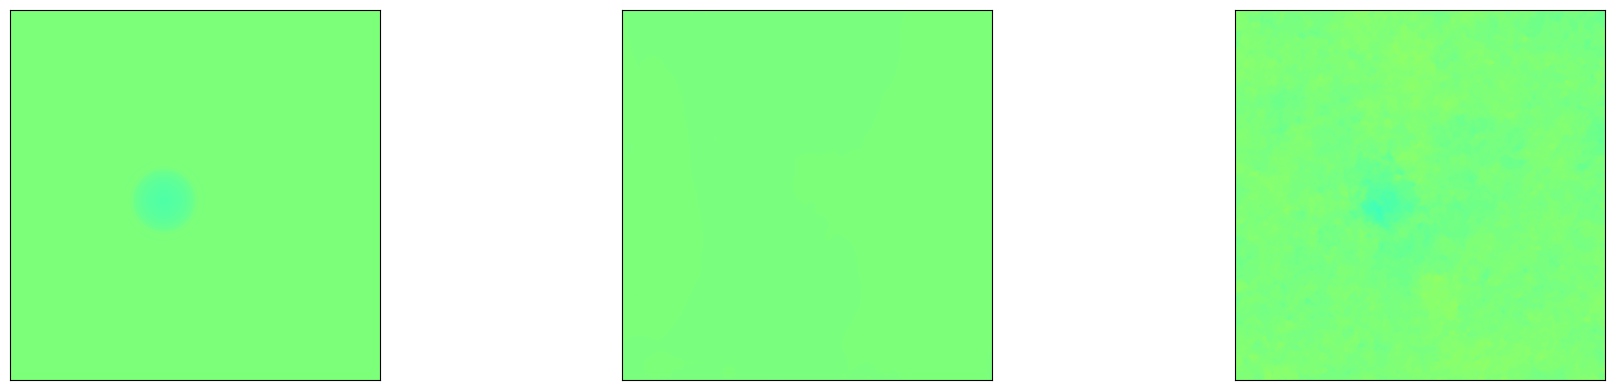

1:1
iter = 0, obj = 2.3915e+10
-- A-update
-- phi-update
-- mean(|\Delta\phi|) = 1.930e-02
iter = 1, obj = 1.5824e+08
-- A-update
-- phi-update
-- mean(|\Delta\phi|) = 1.522e-02
iter = 2, obj = 1.3779e+08
-- A-update
-- phi-update
-- mean(|\Delta\phi|) = 1.233e-02
iter = 3, obj = 1.2755e+08
-- A-update
-- phi-update
-- mean(|\Delta\phi|) = 1.069e-02
iter = 4, obj = 1.2199e+08
-- A-update
-- phi-update
-- mean(|\Delta\phi|) = 9.804e-03
iter = 5, obj = 1.1931e+08
-- A-update
-- phi-update
-- mean(|\Delta\phi|) = 9.541e-03
iter = 6, obj = 1.1778e+08
-- A-update
-- phi-update
-- mean(|\Delta\phi|) = 8.365e-03
iter = 7, obj = 1.1716e+08
-- A-update
-- phi-update
-- mean(|\Delta\phi|) = 8.275e-03
iter = 8, obj = 1.1709e+08
-- A-update
-- phi-update
-- mean(|\Delta\phi|) = 6.844e-03
iter = 9, obj = 1.1747e+08
-- A-update
-- phi-update
-- mean(|\Delta\phi|) = 6.501e-03
iter = 10, obj = 1.1832e+08
-- A-update
-- phi-update
-- mean(|\Delta\phi|) = 5.239e-03
iter = 11, obj = 1.1936e+08
-- A-updat

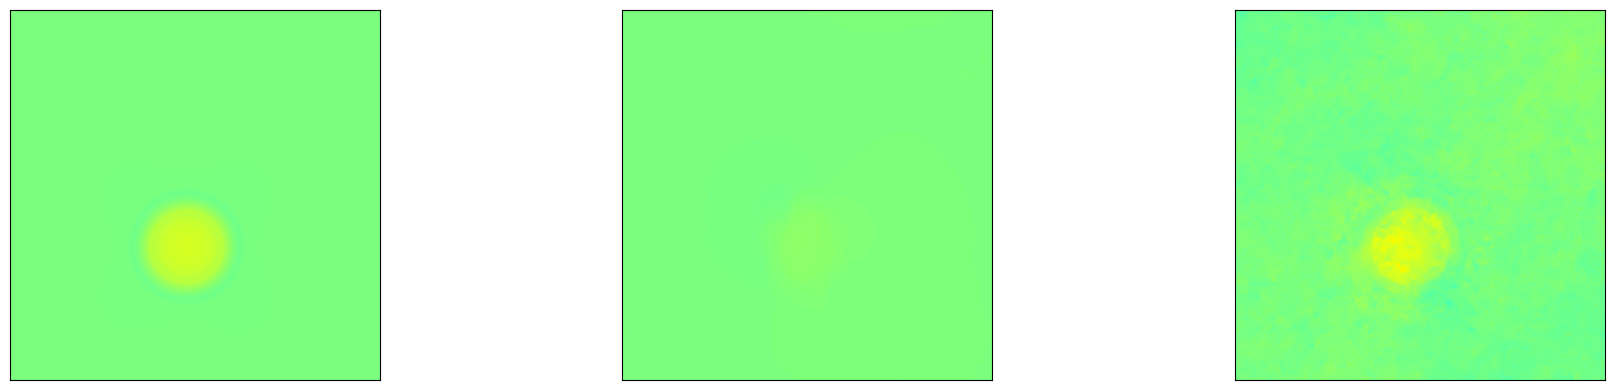

In [ ]:
transforms = utils.OpticalFlowTransformRAFT()
device = "cuda" if torch.cuda.is_available() else "cpu"

np.random.seed(1)
ckpt_num = 1490 # 980

# ckpt = f'runs/2025-07-04/ckpt/RAFT_synthetic_beads_v1_blur_RAFT_l1_{ckpt_num}.pth'
# ckpt = f'runs/2025-07-04/ckpt/RAFT_synthetic_beads_v2_blur_RAFT_l_l1_{ckpt_num}.pth'
# ckpt = f'runs/2025-07-04/ckpt/RAFT_synthetic_beads_v3_blur_RAFT_medianFTarget_l1_{ckpt_num}.pth'
# ckpt = f'runs/2025-07-05/ckpt/RAFT_synthetic_beads_v4_hblur_RAFT_l1_{ckpt_num}.pth'
# ckpt = f'runs/2025-07-09/ckpt/RAFT_synthetic_beads_v5_Hblur_RAFT_hnoise_rcrop_rfocus_l1_{ckpt_num}.pth'
# ckpt = f'runs/2025-07-09/ckpt/RAFT_synthetic_beads_v6_Hblur_RAFT_nnoise_rcrop_rfocus_l1_{ckpt_num}.pth'
# ckpt = f'runs/2025-07-09/ckpt/RAFT_synthetic_beads_v7_Hblur_RAFT_nnoise_rcrop_rlfocus_l1_{ckpt_num}.pth'
# ckpt = f'runs/2025-07-09/ckpt/RAFT_synthetic_beads_v8_Hblur_RAFT_lnoise_rcrop_rlfocus_l1_{ckpt_num}.pth'
# ckpt = f'runs/2025-07-09/ckpt/RAFT_synthetic_beads_v9_hblurField_RAFT_lnoise_rcrop_rlfocus_30Packed_l1_{ckpt_num}.pth'
# ckpt = f'runs/2025-07-14/ckpt/RAFT_synthetic_beads_v10_blur_RAFT_lnoise_rcrop_rnfocus_l1_{ckpt_num}.pth'
# ckpt = f'runs/2025-07-21/ckpt/RAFT_synthetic_cells_v11_blur_RAFT_lnoise_rcrop_rnfocus_l1_{ckpt_num}.pth'
# ckpt = f'runs/2025-07-22/ckpt/RAFT_synthetic_cells_v12_blur_RAFT_lnoise_conv3_l1_{ckpt_num}.pth' # 200
# ckpt = f'runs/2025-07-22/ckpt/RAFT_synthetic_cells_v13_blur_RAFT_lnoise_conv3_gt_l1_{ckpt_num}.pth'
ckpt = f'runs/2025-08-11/ckpt/RAFT_synthetic_beads_v15_blur_RAFT_lnoise_r0crop_rnfocus_l1_{ckpt_num}.pth'
# ckpt = f'runs/2025-08-13/ckpt/RAFT_synthetic_beads_v16_0blur_RAFT_lnoise_r0crop_rnfocus_seed0_l1_{ckpt_num}.pth'

if 'model' in locals():
    print('Updating weights')
    model.load_state_dict(torch.load(ckpt, map_location=torch.device(device)))
else:
    model = init_model_RAFT(raft_large(progress=False), device=device, checkpoint=ckpt)

wc_reconstructor = cws_module.CWS()

losses_wc = []
losses_NN = []

epochs = 2

for it1 in range(epochs):
    
    # generate phase mask
    phase_mask = create_phase_mask([2, 4], np.array(grid_shape)*mag2, tile_size, wl, RI_pm, 
                            smoothing=pm_smoothing, padding=1)[:-1, :-1]

        # generate data 3D tensor
    num_elements = np.random.randint(1, 2)
    print(f'{it1}:{num_elements}')
    
    RI_distribution_1 = geometry.generate_bead_data(geom, c_m, c_v, rad_params, RI_params, num_elements).get_grid()
    geom.reset_grid()
    
    # generate NN input and label
    dist_m_im_var = np.random.rand()*2e-3 - 0.5e-3
    f_plane_delta = np.random.randn()*4e-6
    
    ref_wave, obj_wave, gt_flow = generate_ref_obj_wavefields_from_vol_v2(RI_distribution_1, phase_mask, dist_m_im, dist_m_im_var, 
                                    wl, n_background, spatial_resolution, spatial_support, 
                                    mag=mag, focal_plan_var=f_plane_delta, padding=pad, NA=NA,
                                    partial_coherence_smoothing=partial_coherence_smoothing, 
                                    im_to_ob_space_scale=im_to_ob_space_scale)
    
    img_ref = torch.clamp(torch.abs(torch.tensor(ref_wave[::2, ::2]))**2 + int_gaus_noise*torch.randn(495, 495), min=0).float()
    img_obj = torch.clamp(torch.abs(torch.tensor(obj_wave[::2, ::2]))**2 + int_gaus_noise*torch.randn(495, 495), min=0).float()
    
    img1_batch_val_cell, img2_batch_val_cell = utils.preprocess([img_ref/torch.mean(img_ref)], [img_obj/torch.mean(img_obj)], transforms)

    model.eval()
    with torch.no_grad():
        list_of_flows_val = model(img1_batch_val_cell.to(device), img2_batch_val_cell.to(device))
        predicted_flows_val = F.resize(list_of_flows_val[-1].detach().cpu(), size=(img_obj.shape))

        opd_NN = 1*utils.int_2d_fourier([predicted_flows_val[0, 0], predicted_flows_val[0, 1]], (6e-6)**2/(dist_m_im+dist_m_im_var))/(2*np.pi)
        
    _, _, loss_wc = wc_reconstructor.run(10000*np.array(img_ref).astype(np.float64), 
                    10000*np.array(img_obj).astype(np.float64), 
                    prior=[100, 1000, 100, 5], 
                    # prior=[1e-2, 1e-1, 1e-2, 1e-2], 
                    # prior=[1e-1, 40, 100, 5],
                    # prior=[100, 100, 100, 5],  
                    iter=[15, 10, 10], tol=1e-4)
    _, opd_wc = wc_reconstructor.get_field(pixel_size=6e-6, z=dist_m_im+dist_m_im_var, RI=2.)
    
    opd_wc = -1*opd_wc
    fig, axs = plt.subplots(1, 3, figsize=(20, 4))

    gt_flow = [gt_flow[0][::2, ::2], gt_flow[1][::2, ::2]]
    gt = 1*(6e-6)**2/(dist_m_im+dist_m_im_var)*utils.int_2d_fourier(gt_flow, 1)/(2*np.pi)
    cm0 = axs[0].imshow(gt*1e6, cmap='jet', 
                        vmax=0.15, vmin=-0.15)
    # plt.colorbar(cm0, ax=axs[0])

    cm1 = axs[1].imshow(opd_NN*1e6, cmap='jet', vmax=0.15, vmin=-0.15)
    # plt.colorbar(cm1, ax=axs[1])

    cm2 = axs[2].imshow(opd_wc*1e6, cmap='jet', vmax=0.15, vmin=-0.15)
    # plt.colorbar(cm2, ax=axs[2])

    for i in range(3):
        axs[i].set_xticks([])
        axs[i].set_yticks([])
    
    losses_wc.append(np.linalg.norm(gt*1e6 - opd_wc*1e6))
    losses_NN.append(np.linalg.norm(gt*1e6 - opd_NN*1e6))
    
    plt.tight_layout()
    plt.show()

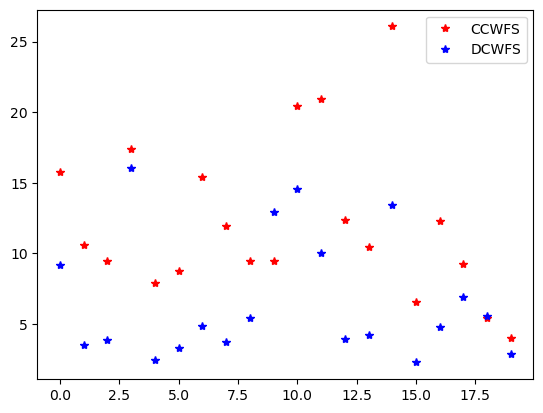

12.193624963022774 6.697984162436048


In [5]:
plt.plot(losses_wc, 'r*', label='CCWFS')
plt.plot(losses_NN, 'b*', label='DCWFS')

plt.legend()
plt.show()

print(np.array(losses_wc).mean(), np.array(losses_NN).mean())

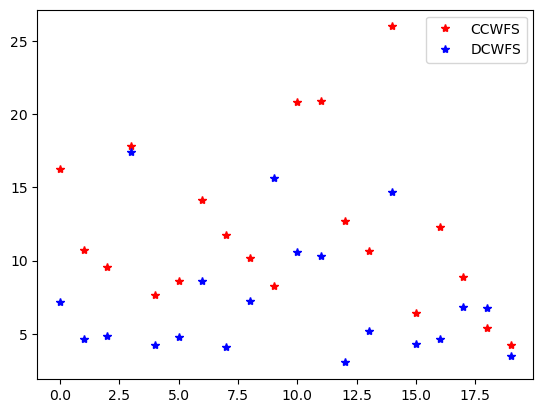

12.156282148220535 7.4267565086553375


In [9]:
plt.plot(losses_wc, 'r*', label='CCWFS')
plt.plot(losses_NN, 'b*', label='DCWFS')

plt.legend()
plt.show()

print(np.array(losses_wc).mean(), np.array(losses_NN).mean())


In [41]:
# opd_NN.shape, opd_wc.shape, gt.shape
plt.imshow(np.hstack([gt*1e6, opd_NN*1e6, opd_wc*1e6]), cmap='jet', vmin=-0.25, vmax=0.25)
plt.xticks([])
plt.yticks([])
plt.tight_layout()
# plt.colorbar()
plt.savefig('temp.png', pad_inches=0, bbox_inches='tight')
plt.close()

In [33]:
opd_NN.size

245025

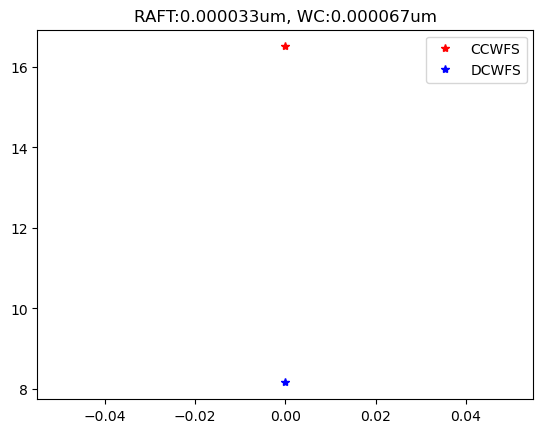

In [39]:
plt.plot(losses_wc, 'r*', label='CCWFS')
plt.plot(losses_NN, 'b*', label='DCWFS')
plt.title(f'RAFT:{np.array(losses_NN).mean()/opd_NN.size:4f}um, WC:{np.array(losses_wc).mean()/opd_wc.size:4f}um')

plt.legend()
plt.savefig('temp2.png', pad_inches=0)

# Synthetic Cell Data and Figure

In [16]:
def generate_cell(HEK_params, cart, meshgrid, mean_var=5e-4, std_var=5, ran_crop=True, ran_flip=True, ran_rotate=True):
    
    temp_coeffs = std_var*HEK_params[1]*np.random.rand(861) + HEK_params[0] + mean_var*np.random.rand(861)
    gen_cell = np.where(cart.eval_grid(temp_coeffs, matrix=True) < 0.005, 0., cart.eval_grid(temp_coeffs, matrix=True))
    gen_cell = np.where(meshgrid[0]**2 + meshgrid[1]**2 > 0.5, 0., gen_cell)
    
    if ran_crop:
        # random crop -> displace the cell and change the size of the cell
        ch = 50 + np.random.randint(-50, 100)
        cv = -50 + np.random.randint(-100, 50)
        
        gen_cell = gen_cell[ch:cv, ch:cv]
        
        crop_odd = (ch -1*cv) % 2 == 1
        pad_by = np.ceil((ch -1*cv)/2).astype(int)
        if crop_odd:
            gen_cell = gen_cell[:-1, :-1]
            
        gen_cell = np.pad(gen_cell, pad_by)
        
    if ran_flip:
        gen_cell = np.flip(gen_cell, axis=np.random.randint(0, 2))
        gen_cell = np.flip(gen_cell, axis=np.random.randint(0, 2))
        
    if ran_rotate:
        gen_cell = scipy.ndimage.rotate(gen_cell, np.random.randint(-45, 45), reshape=False)
    
    return gen_cell

In [96]:
def generate_ref_obj_wavefields_HEK_cells(synth_cell, phase_mask, dist_m_im, dist_m_im_var,
                                wl, spatial_resolution, f_plane_delta=30e-6, padding=256, conv_opt_dx=3):
    """Propagate the synthetic cell through the phase mask and record the object and ref wavefields

    Args:
        synth_cell (array): OPD of generated cell [meters]
        phase_mask (array): phase mask  in radians
        dist_m_im (float): nominal disance bw mask and sensor
        dist_m_im_var (float): variation in mask-sensor distance
        wl (float): wavelength
        spatial_resolution (list):resolution oof simulation in image space
        f_plane_delta (float, optional): Distance planar cell travel to have amplitude features. Defaults to 3e-3.
        padding (int, optional): _description_. Defaults to 256.

    Returns:
        ref_image_sensor (float): magnitude of ref speckle field
        obj_image_sensor (gloat): magnitude of object speckle field
        gt_flow (list): scaled gradients of object
    """
    
    k = 2*np.pi/wl

    # adds features to the amp which show up in the intensity but also add diffraction due to prop
    output_field = propagator.propagate(np.exp(1j*k*synth_cell), wl, np.array(spatial_resolution)/10, f_plane_delta, 
                                        padding=padding, direction='forward')
    # pass through radially reducing RI in a multislice model for circular object to simulate less bend on the edges and more in the center.

    # from image plane prop back to mask plane from image plane (plus variation) ensures focus plane imaging
    output_field = propagator.propagate(output_field, wl, spatial_resolution, dist_m_im + dist_m_im_var, 
                                            padding=padding, direction='backward')
    output_field = gaussian_filter(output_field, np.random.randint(2, 4, size=1)[0]) # smoothing -> partial spatial coherence. Also, gradient spreads, beocmes visible in amplitude
    
    # ground truth flow

    flow_y, flow_x = utils.grad_optr(np.angle(output_field))
    gt_flow_y = (np.remainder(flow_y + np.pi, 2*np.pi) - np.pi)
    gt_flow_x = (np.remainder(flow_x + np.pi, 2*np.pi) - np.pi)
    
    # # aerial to sensor flow
    # conv_opt = np.ones([conv_opt_dx, conv_opt_dx])
    # gt_flow_y = scipy.signal.convolve2d(gt_flow_y, conv_opt, mode='same')[::conv_opt_dx, ::conv_opt_dx]
    # gt_flow_x = scipy.signal.convolve2d(gt_flow_x, conv_opt, mode='same')[::conv_opt_dx, ::conv_opt_dx]
    
    # gt_flow_y = gt_flow_y/(conv_opt_dx*spatial_resolution[0])**2/k*(dist_m_im + dist_m_im_var)
    # gt_flow_x = gt_flow_x/(conv_opt_dx*spatial_resolution[1])**2/k*(dist_m_im + dist_m_im_var)
    
    gt_flow_y = gt_flow_y/(spatial_resolution[0])**2/k*(dist_m_im + dist_m_im_var)
    gt_flow_x = gt_flow_x/(spatial_resolution[1])**2/k*(dist_m_im + dist_m_im_var)
    
    # mask modulation and prop to image plane
    output_field = propagator.propagate(output_field*phase_mask, wl, spatial_resolution, dist_m_im + dist_m_im_var, 
                                        padding=padding, direction='forward')
    ref_field = propagator.propagate(phase_mask, wl, spatial_resolution, dist_m_im + dist_m_im_var, 
                                        padding=padding, direction='forward')
    
    # # aerial to sensor image
    # ref_image_sensor = scipy.signal.convolve2d(np.abs(ref_field)**2, 
    #                                            conv_opt, mode='same')[::conv_opt_dx, ::conv_opt_dx]
    # obj_image_sensor = scipy.signal.convolve2d(np.abs(output_field)**2, 
    #                                            conv_opt, mode='same')[::conv_opt_dx, ::conv_opt_dx] 
    
    # # normalize and add gaussian with sigma 1.5/median 1 before inpit to network to match collected images
    # ref_image_sensor = median_filter(ref_image_sensor/ref_image_sensor.max(), 1)
    # obj_image_sensor = median_filter(obj_image_sensor/obj_image_sensor.max(), 1)
              
    # return ref_image_sensor[5:-5, 5:-5], obj_image_sensor[5:-5, 5:-5], [gt_flow_x[5:-5, 5:-5], gt_flow_y[5:-5, 5:-5]]
    return ref_field[5:-5, 5:-5], output_field[5:-5, 5:-5], [gt_flow_x[5:-5, 5:-5], gt_flow_y[5:-5, 5:-5]]


In [10]:
print('Loading Zernike polynomials')
cart = RZern(40)
L, K = 800, 800
ddx = np.linspace(-1.0, 1.0, L)
ddy = np.linspace(-1.0, 1.0, K)
xv, yv = np.meshgrid(ddx, ddy)
cart.make_cart_grid(xv, yv)

Loading Zernike polynomials


In [11]:
HEK_mean = scipy.io.loadmat(f'HEK_synth_data_generstor.mat')['mean'].ravel()
HEK_std = scipy.io.loadmat(f'HEK_synth_data_generstor.mat')['std'].ravel()
synth_cell_opd = 1e-6*generate_cell([HEK_mean, HEK_std], cart, [xv, yv], mean_var=5e-4, std_var=8, ran_crop=False, ran_flip=False, ran_rotate=False) # shape [L, K]


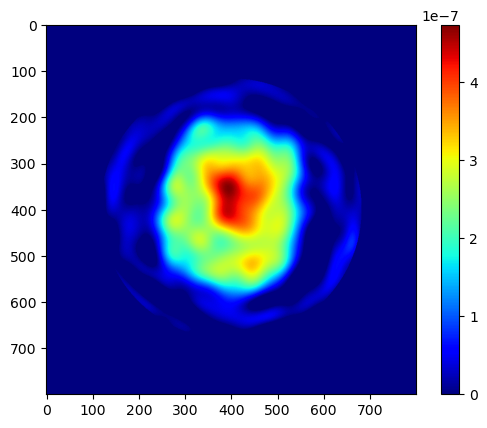

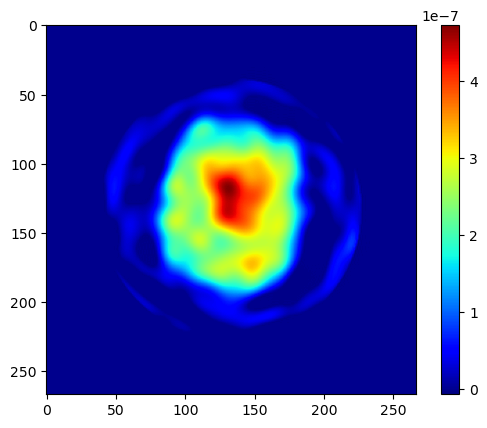

In [114]:
np.random.seed(0)

synth_cell_opd = 1e-6*generate_cell([HEK_mean, HEK_std], cart, [xv, yv], mean_var=5e-4, std_var=8, ran_crop=False, ran_flip=False, ran_rotate=False) # shape [L, K]
plt.imshow(synth_cell_opd, cmap='jet')
plt.colorbar()
plt.show()

# generate NN input and label
dist_m_im = 1.43e-3
dist_m_im_var = np.random.randn()*1e-3


k = 2*np.pi/wl
output_field = np.exp(1j*k*synth_cell_opd)
flow_y, flow_x = utils.grad_optr(np.angle(output_field))

# plt.imshow(median_filter(flow_x, 3), vmin=-0.1, vmax=0.1)
# plt.colorbar()
# plt.show()

gt_flow_y = (np.remainder(flow_y + np.pi, 2*np.pi) - np.pi)
gt_flow_x = (np.remainder(flow_x + np.pi, 2*np.pi) - np.pi)

# # gt_flow_y = median_filter(flow_y, 7)
# # gt_flow_x = median_filter(flow_x, 7)


# # gt_flow_x = np.where(np.abs(flow_x) > 1, np.mean(flow_x[flow_x>0]), flow_x)
# # gt_flow_y = np.where(np.abs(flow_y) > 1, np.mean(flow_y[flow_y>0]), flow_y)

# plt.imshow(gt_flow_x)
# plt.colorbar()
# plt.show()

# gt_flow_y = gt_flow_y/(spatial_resolution[0])**2/k*(dist_m_im + dist_m_im_var)
# gt_flow_x = gt_flow_x/(spatial_resolution[1])**2/k*(dist_m_im + dist_m_im_var)

# plt.imshow(gt_flow_x)
# plt.colorbar()
# plt.show()

conv_opt_dx = 3
conv_opt = np.ones([conv_opt_dx, conv_opt_dx])
gt_flow_y = scipy.signal.convolve2d(gt_flow_y, conv_opt, mode='same')[::conv_opt_dx, ::conv_opt_dx]
gt_flow_x = scipy.signal.convolve2d(gt_flow_x, conv_opt, mode='same')[::conv_opt_dx, ::conv_opt_dx]

gt_flow_y = gt_flow_y/(conv_opt_dx*spatial_resolution[0])**2/k*(dist_m_im + dist_m_im_var)
gt_flow_x = gt_flow_x/(conv_opt_dx*spatial_resolution[1])**2/k*(dist_m_im + dist_m_im_var)

# gt_flow = [gt_flow_x[::1, ::1], gt_flow_y[::1, ::1]]
# gt = 1*utils.int_2d_fourier(gt_flow, 1/k)

gt_flow = [gt_flow_x, gt_flow_y]
gt = 1*utils.int_2d_fourier(gt_flow, 3*(spatial_resolution[0])**2/(dist_m_im+dist_m_im_var))

bk_mean = gt[:50, :].mean()

plt.imshow(gt - bk_mean, cmap='jet')
plt.colorbar()
plt.show()

Updating weights
0


/tmp/ipykernel_27811/3102695333.py:44: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(ckpt, map_location=torch.device(device)))


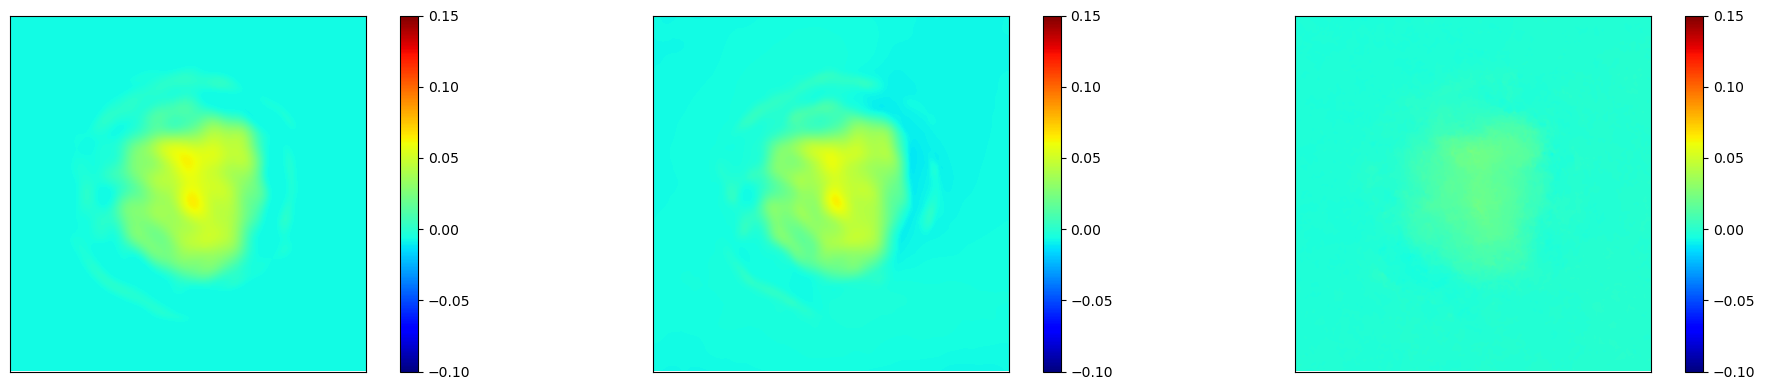

In [110]:
np.random.seed(1)
# HEK cell generator parameters
HEK_mean = scipy.io.loadmat(f'HEK_synth_data_generstor.mat')['mean'].ravel()
HEK_std = scipy.io.loadmat(f'HEK_synth_data_generstor.mat')['std'].ravel()

# Grid and propagation parameters setup
wl = 640e-9
spatial_resolution = [2e-6, 2e-6, 2e-6] # dx, dy, dz
spatial_support = [spatial_resolution[i]*[L, K][i] for i in range(2)]

dist_m_im = 2e-3 # meters
pad = 256

side_length = 10e-6
tile_size = int(side_length/(spatial_resolution[0]))
RI_pm = 1.46
pm_smoothing = 4

int_gaus_noise = 2e-3
    
transforms = utils.OpticalFlowTransformRAFT()
device = "cuda" if torch.cuda.is_available() else "cpu"

ckpt_num = 1400 # 980

# ckpt = f'runs/2025-07-04/ckpt/RAFT_synthetic_beads_v1_blur_RAFT_l1_{ckpt_num}.pth'
# ckpt = f'runs/2025-07-04/ckpt/RAFT_synthetic_beads_v2_blur_RAFT_l_l1_{ckpt_num}.pth'
# ckpt = f'runs/2025-07-04/ckpt/RAFT_synthetic_beads_v3_blur_RAFT_medianFTarget_l1_{ckpt_num}.pth'
# ckpt = f'runs/2025-07-05/ckpt/RAFT_synthetic_beads_v4_hblur_RAFT_l1_{ckpt_num}.pth'
# ckpt = f'runs/2025-07-09/ckpt/RAFT_synthetic_beads_v5_Hblur_RAFT_hnoise_rcrop_rfocus_l1_{ckpt_num}.pth'
# ckpt = f'runs/2025-07-09/ckpt/RAFT_synthetic_beads_v6_Hblur_RAFT_nnoise_rcrop_rfocus_l1_{ckpt_num}.pth'
# ckpt = f'runs/2025-07-09/ckpt/RAFT_synthetic_beads_v7_Hblur_RAFT_nnoise_rcrop_rlfocus_l1_{ckpt_num}.pth'
# ckpt = f'runs/2025-07-09/ckpt/RAFT_synthetic_beads_v8_Hblur_RAFT_lnoise_rcrop_rlfocus_l1_{ckpt_num}.pth'
# ckpt = f'runs/2025-07-09/ckpt/RAFT_synthetic_beads_v9_hblurField_RAFT_lnoise_rcrop_rlfocus_30Packed_l1_{ckpt_num}.pth'
# ckpt = f'runs/2025-07-14/ckpt/RAFT_synthetic_beads_v10_blur_RAFT_lnoise_rcrop_rnfocus_l1_{ckpt_num}.pth'
# ckpt = f'runs/2025-07-21/ckpt/RAFT_synthetic_cells_v11_blur_RAFT_lnoise_rcrop_rnfocus_l1_{ckpt_num}.pth'
# ckpt = f'runs/2025-07-22/ckpt/RAFT_synthetic_cells_v12_blur_RAFT_lnoise_conv3_l1_{ckpt_num}.pth' # 200
ckpt = f'runs/2025-07-22/ckpt/RAFT_synthetic_cells_v13_blur_RAFT_lnoise_conv3_gt_l1_{ckpt_num}.pth'
# ckpt = f'runs/2025-08-11/ckpt/RAFT_synthetic_beads_v15_blur_RAFT_lnoise_r0crop_rnfocus_l1_{ckpt_num}.pth'
# ckpt = f'runs/2025-08-13/ckpt/RAFT_synthetic_beads_v16_0blur_RAFT_lnoise_r0crop_rnfocus_seed0_l1_{ckpt_num}.pth'

if 'model' in locals():
    print('Updating weights')
    model.load_state_dict(torch.load(ckpt, map_location=torch.device(device)))
else:
    model = init_model_RAFT(raft_large(progress=False), device=device, checkpoint=ckpt)

wc_reconstructor = cws_module.CWS()

losses_wc = []
losses_NN = []

epochs = 1
for it1 in range(epochs):
    # generate phase mask
    print(it1)
    phase_mask = create_phase_mask([3, 6], (L, K), tile_size, wl, RI_pm, smoothing=pm_smoothing)

    synth_cell_opd = 1e-6*generate_cell([HEK_mean, HEK_std], cart, [xv, yv], mean_var=5e-4, std_var=8, ran_crop=False, ran_flip=False, ran_rotate=False) # shape [L, K]

    # generate NN input and label
    dist_m_im_var = np.random.randn()*1e-3
    f_plane_delta = np.random.randint(20, 40, size=1)[0]*1e-6
    ref_wave, obj_wave, gt_flow = generate_ref_obj_wavefields_HEK_cells(synth_cell_opd, phase_mask, dist_m_im, dist_m_im_var,
                        wl, spatial_resolution, f_plane_delta=f_plane_delta, padding=pad)
    
    img_ref = torch.clamp(torch.abs(torch.tensor(ref_wave[::1, ::1]))**2 + int_gaus_noise*torch.randn(395*2, 395*2), min=0).float()
    img_obj = torch.clamp(torch.abs(torch.tensor(obj_wave[::1, ::1]))**2 + int_gaus_noise*torch.randn(395*2, 395*2), min=0).float()
    
    img1_batch_val_cell, img2_batch_val_cell = utils.preprocess([img_ref/torch.mean(img_ref)], [img_obj/torch.mean(img_obj)], transforms)

    model.eval()
    with torch.no_grad():
        list_of_flows_val = model(img1_batch_val_cell.to(device), img2_batch_val_cell.to(device))
        predicted_flows_val = F.resize(list_of_flows_val[-1].detach().cpu(), size=(img_obj.shape))

    # opd_NN = -1*utils.int_2d_fourier([predicted_flows_val[0, 0], predicted_flows_val[0, 1]], (6e-6)**2/(dist_m_im+dist_m_im_var))/(2*np.pi)
    opd_NN = 1*utils.int_2d_fourier([predicted_flows_val[0, 0], predicted_flows_val[0, 1]], (2e-6)**2/(dist_m_im+dist_m_im_var))/(2*np.pi)

    
    with utils.HiddenPrints():
        _, _, loss_wc = wc_reconstructor.run(10000*np.array(img_ref).astype(np.float64), 
                        10000*np.array(img_obj).astype(np.float64), 
                        prior=[100, 1000, 100, 5], 
                        # prior=[1e-2, 1e-1, 1e-2, 1e-2], 
                        # prior=[1e-1, 40, 100, 5],
                        # prior=[100, 100, 100, 5],  
                        iter=[15, 10, 10], tol=1e-4)
    _, opd_wc = wc_reconstructor.get_field(pixel_size=2e-6, z=dist_m_im+dist_m_im_var, RI=2.)
    
    fig, axs = plt.subplots(1, 3, figsize=(20, 4))

    gt_flow = [gt_flow[0][::1, ::1], gt_flow[1][::1, ::1]]
    gt = 1*(2e-6)**2/(dist_m_im+dist_m_im_var)*utils.int_2d_fourier(gt_flow, 1)/(2*np.pi)
    cm0 = axs[0].imshow(gt*1e6, cmap='jet', 
                        vmax=0.15, vmin=-0.1)
    plt.colorbar(cm0, ax=axs[0])

    cm1 = axs[1].imshow(opd_NN*1e6, cmap='jet', vmax=0.15, vmin=-0.1)
    plt.colorbar(cm1, ax=axs[1])

    cm2 = axs[2].imshow(opd_wc*1e6, cmap='jet', vmax=0.15, vmin=-0.1)
    plt.colorbar(cm2, ax=axs[2])

    for i in range(3):
        axs[i].set_xticks([])
        axs[i].set_yticks([])
    
    losses_wc.append(np.linalg.norm(gt*1e6 - opd_wc*1e6))
    losses_NN.append(np.linalg.norm(gt*1e6 - opd_NN*1e6))
    
    plt.tight_layout()
    plt.show()

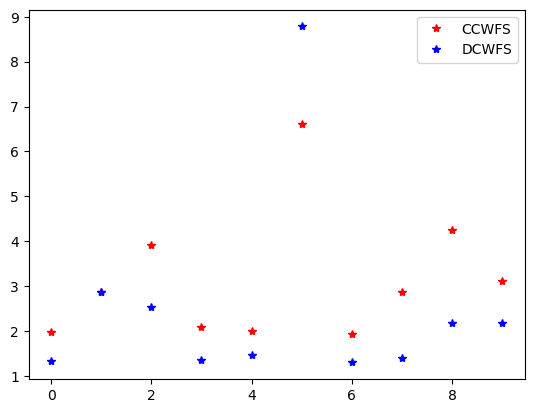

3.1643356266317433 2.538265154342577


In [9]:
plt.plot(losses_wc, 'r*', label='CCWFS')
plt.plot(losses_NN, 'b*', label='DCWFS')

plt.legend()
plt.show()

print(np.array(losses_wc).mean(), np.array(losses_NN).mean())

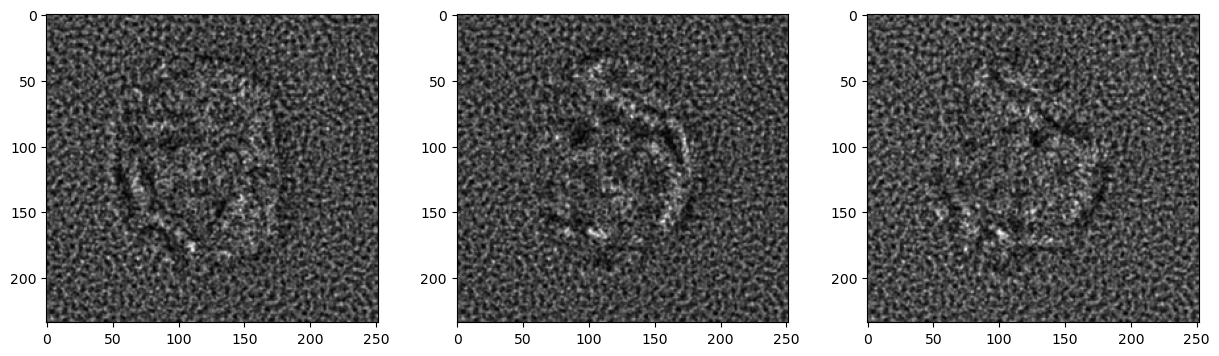

In [107]:
# validation cell video

cell_ref = tifffile.imread('data/cell_video/measurement/ref_cell_4.tif')[100:-150, 50:-20]
cell_obj_arr = tifffile.imread('data/cell_video/measurement/cell_4_0.tif')[::100, 100:-150, 50:-20]

fig, axs = plt.subplots(1, 3, figsize=(15, 4))

axs[0].imshow(cell_obj_arr[0], cmap='gray')
axs[1].imshow(cell_obj_arr[1], cmap='gray')
axs[2].imshow(cell_obj_arr[2], cmap='gray')

plt.show()

Updating weights


/tmp/ipykernel_27811/1734656647.py:25: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(ckpt, map_location=torch.device(device)))


iter = 0, obj = 2.2136e+10
-- A-update
-- phi-update
-- mean(|\Delta\phi|) = 5.302e-01
iter = 1, obj = 1.4801e+09
-- A-update
-- phi-update
-- mean(|\Delta\phi|) = 4.135e-01
iter = 2, obj = 1.1819e+09
-- A-update
-- phi-update
-- mean(|\Delta\phi|) = 3.187e-01
iter = 3, obj = 9.9335e+08
-- A-update
-- phi-update
-- mean(|\Delta\phi|) = 2.521e-01
iter = 4, obj = 8.8580e+08
-- A-update
-- phi-update
-- mean(|\Delta\phi|) = 2.151e-01
iter = 5, obj = 8.0451e+08
-- A-update
-- phi-update
-- mean(|\Delta\phi|) = 1.678e-01
iter = 6, obj = 7.5477e+08
-- A-update
-- phi-update
-- mean(|\Delta\phi|) = 1.390e-01
iter = 7, obj = 7.2173e+08
-- A-update
-- phi-update
-- mean(|\Delta\phi|) = 1.165e-01
iter = 8, obj = 7.0029e+08
-- A-update
-- phi-update
-- mean(|\Delta\phi|) = 9.605e-02
iter = 9, obj = 6.8701e+08
-- A-update
-- phi-update
-- mean(|\Delta\phi|) = 7.525e-02
iter = 10, obj = 6.8121e+08
-- A-update
-- phi-update
-- mean(|\Delta\phi|) = 7.406e-02
iter = 11, obj = 6.7308e+08
-- A-update
--

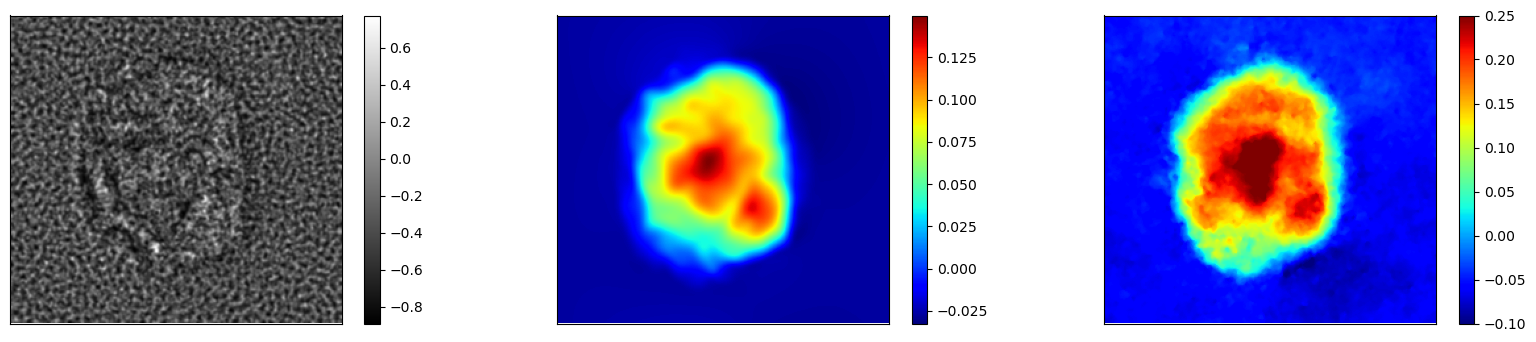

iter = 0, obj = 2.6377e+10
-- A-update
-- phi-update
-- mean(|\Delta\phi|) = 5.581e-01
iter = 1, obj = 1.4861e+09
-- A-update
-- phi-update
-- mean(|\Delta\phi|) = 4.372e-01
iter = 2, obj = 1.1717e+09
-- A-update
-- phi-update
-- mean(|\Delta\phi|) = 3.323e-01
iter = 3, obj = 9.8527e+08
-- A-update
-- phi-update
-- mean(|\Delta\phi|) = 2.775e-01
iter = 4, obj = 8.6670e+08
-- A-update
-- phi-update
-- mean(|\Delta\phi|) = 2.194e-01
iter = 5, obj = 7.9107e+08
-- A-update
-- phi-update
-- mean(|\Delta\phi|) = 1.807e-01
iter = 6, obj = 7.4242e+08
-- A-update
-- phi-update
-- mean(|\Delta\phi|) = 1.535e-01
iter = 7, obj = 7.0678e+08
-- A-update
-- phi-update
-- mean(|\Delta\phi|) = 1.253e-01
iter = 8, obj = 6.8137e+08
-- A-update
-- phi-update
-- mean(|\Delta\phi|) = 1.043e-01
iter = 9, obj = 6.6485e+08
-- A-update
-- phi-update
-- mean(|\Delta\phi|) = 8.447e-02
iter = 10, obj = 6.5024e+08
-- A-update
-- phi-update
-- mean(|\Delta\phi|) = 7.058e-02
iter = 11, obj = 6.3975e+08
-- A-update
--

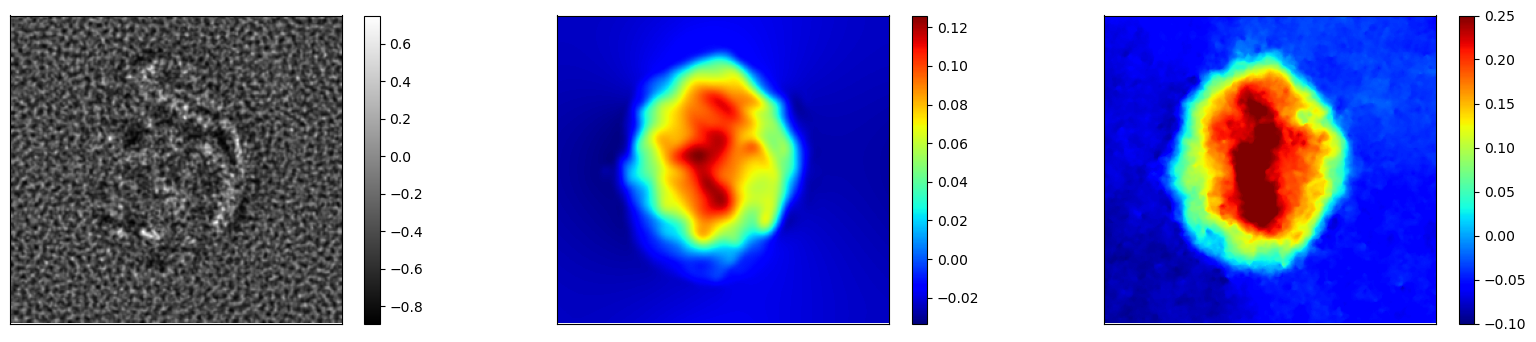

iter = 0, obj = 2.3050e+10
-- A-update
-- phi-update
-- mean(|\Delta\phi|) = 5.271e-01
iter = 1, obj = 1.5467e+09
-- A-update
-- phi-update
-- mean(|\Delta\phi|) = 4.162e-01
iter = 2, obj = 1.2299e+09
-- A-update
-- phi-update
-- mean(|\Delta\phi|) = 3.448e-01
iter = 3, obj = 1.0294e+09
-- A-update
-- phi-update
-- mean(|\Delta\phi|) = 2.790e-01
iter = 4, obj = 9.0571e+08
-- A-update
-- phi-update
-- mean(|\Delta\phi|) = 2.262e-01
iter = 5, obj = 8.2657e+08
-- A-update
-- phi-update
-- mean(|\Delta\phi|) = 1.927e-01
iter = 6, obj = 7.7176e+08
-- A-update
-- phi-update
-- mean(|\Delta\phi|) = 1.514e-01
iter = 7, obj = 7.2993e+08
-- A-update
-- phi-update
-- mean(|\Delta\phi|) = 1.240e-01
iter = 8, obj = 7.0503e+08
-- A-update
-- phi-update
-- mean(|\Delta\phi|) = 1.077e-01
iter = 9, obj = 6.8892e+08
-- A-update
-- phi-update
-- mean(|\Delta\phi|) = 9.288e-02
iter = 10, obj = 6.7866e+08
-- A-update
-- phi-update
-- mean(|\Delta\phi|) = 7.794e-02
iter = 11, obj = 6.6909e+08
-- A-update
--

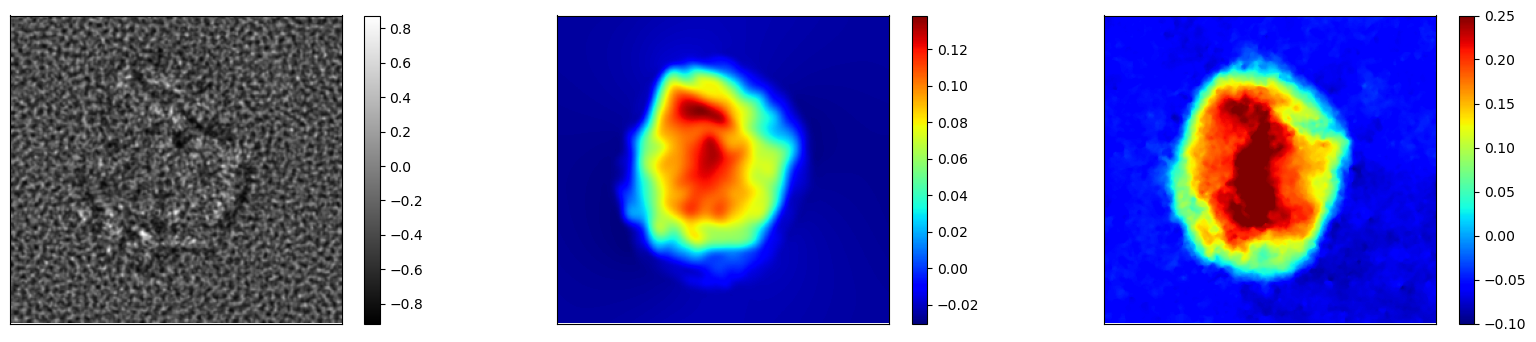

iter = 0, obj = 2.2203e+10
-- A-update
-- phi-update
-- mean(|\Delta\phi|) = 5.502e-01
iter = 1, obj = 1.3859e+09
-- A-update
-- phi-update
-- mean(|\Delta\phi|) = 4.324e-01
iter = 2, obj = 1.0949e+09
-- A-update
-- phi-update
-- mean(|\Delta\phi|) = 3.336e-01
iter = 3, obj = 9.1880e+08
-- A-update
-- phi-update
-- mean(|\Delta\phi|) = 2.643e-01
iter = 4, obj = 8.1466e+08
-- A-update
-- phi-update
-- mean(|\Delta\phi|) = 2.177e-01
iter = 5, obj = 7.4726e+08
-- A-update
-- phi-update
-- mean(|\Delta\phi|) = 1.735e-01
iter = 6, obj = 7.0388e+08
-- A-update
-- phi-update
-- mean(|\Delta\phi|) = 1.360e-01
iter = 7, obj = 6.7551e+08
-- A-update
-- phi-update
-- mean(|\Delta\phi|) = 1.157e-01
iter = 8, obj = 6.5498e+08
-- A-update
-- phi-update
-- mean(|\Delta\phi|) = 9.964e-02
iter = 9, obj = 6.4464e+08
-- A-update
-- phi-update
-- mean(|\Delta\phi|) = 8.150e-02
iter = 10, obj = 6.3363e+08
-- A-update
-- phi-update
-- mean(|\Delta\phi|) = 6.590e-02
iter = 11, obj = 6.2798e+08
-- A-update
--

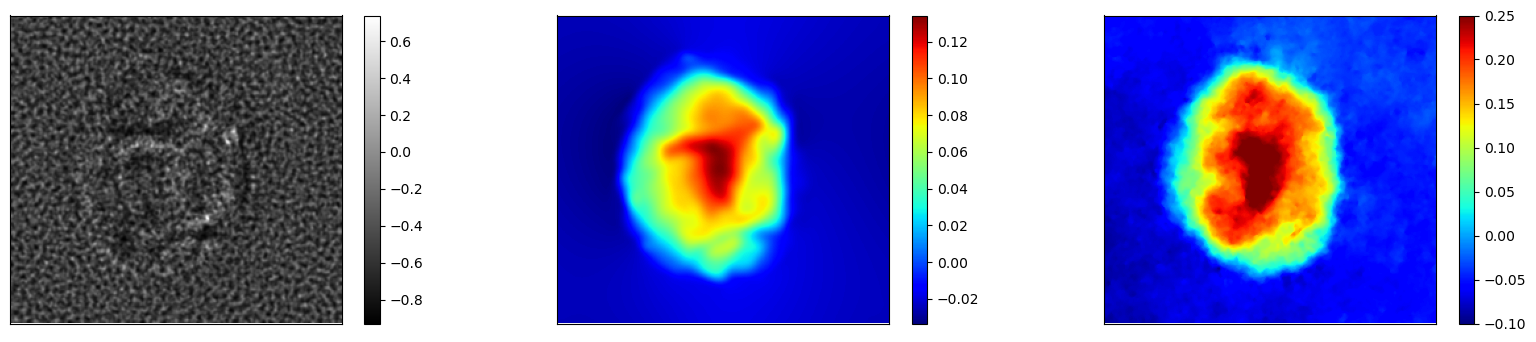

iter = 0, obj = 2.1074e+10
-- A-update
-- phi-update
-- mean(|\Delta\phi|) = 5.469e-01
iter = 1, obj = 1.6081e+09
-- A-update
-- phi-update
-- mean(|\Delta\phi|) = 4.239e-01
iter = 2, obj = 1.2671e+09
-- A-update
-- phi-update
-- mean(|\Delta\phi|) = 3.438e-01
iter = 3, obj = 1.0586e+09
-- A-update
-- phi-update
-- mean(|\Delta\phi|) = 2.771e-01
iter = 4, obj = 9.2820e+08
-- A-update
-- phi-update
-- mean(|\Delta\phi|) = 2.176e-01
iter = 5, obj = 8.4495e+08
-- A-update
-- phi-update
-- mean(|\Delta\phi|) = 1.879e-01
iter = 6, obj = 7.9560e+08
-- A-update
-- phi-update
-- mean(|\Delta\phi|) = 1.564e-01
iter = 7, obj = 7.5974e+08
-- A-update
-- phi-update
-- mean(|\Delta\phi|) = 1.364e-01
iter = 8, obj = 7.3358e+08
-- A-update
-- phi-update
-- mean(|\Delta\phi|) = 1.145e-01
iter = 9, obj = 7.2105e+08
-- A-update
-- phi-update
-- mean(|\Delta\phi|) = 8.978e-02
iter = 10, obj = 7.1200e+08
-- A-update
-- phi-update
-- mean(|\Delta\phi|) = 8.331e-02
iter = 11, obj = 7.0714e+08
-- A-update
--

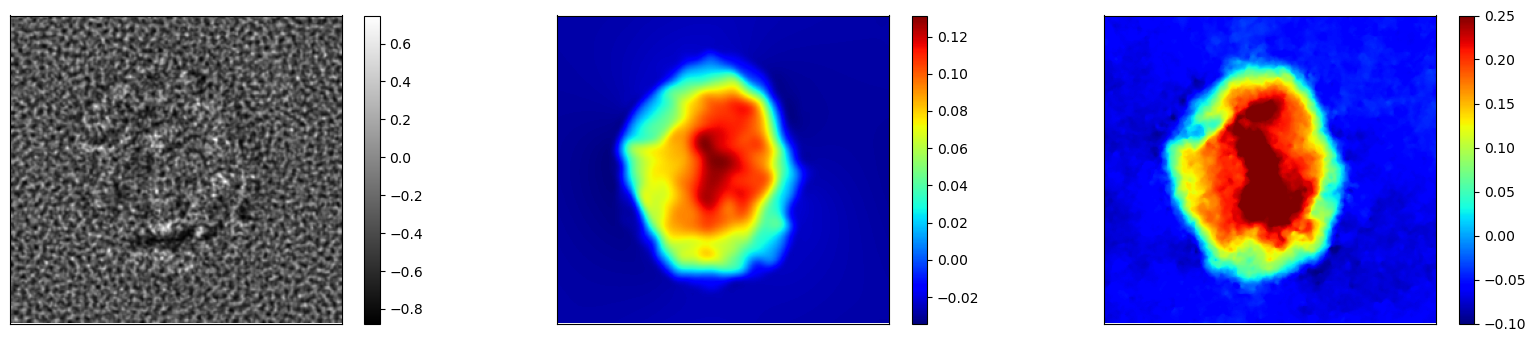

In [108]:
device = "cuda" if torch.cuda.is_available() else "cpu"

ckpt_num = 1400 # 980

# ckpt = f'runs/2025-07-04/ckpt/RAFT_synthetic_beads_v1_blur_RAFT_l1_{ckpt_num}.pth'
# ckpt = f'runs/2025-07-04/ckpt/RAFT_synthetic_beads_v2_blur_RAFT_l_l1_{ckpt_num}.pth'
# ckpt = f'runs/2025-07-04/ckpt/RAFT_synthetic_beads_v3_blur_RAFT_medianFTarget_l1_{ckpt_num}.pth'
# ckpt = f'runs/2025-07-05/ckpt/RAFT_synthetic_beads_v4_hblur_RAFT_l1_{ckpt_num}.pth'
# ckpt = f'runs/2025-07-09/ckpt/RAFT_synthetic_beads_v5_Hblur_RAFT_hnoise_rcrop_rfocus_l1_{ckpt_num}.pth'
# ckpt = f'runs/2025-07-09/ckpt/RAFT_synthetic_beads_v6_Hblur_RAFT_nnoise_rcrop_rfocus_l1_{ckpt_num}.pth'
# ckpt = f'runs/2025-07-09/ckpt/RAFT_synthetic_beads_v7_Hblur_RAFT_nnoise_rcrop_rlfocus_l1_{ckpt_num}.pth'
# ckpt = f'runs/2025-07-09/ckpt/RAFT_synthetic_beads_v8_Hblur_RAFT_lnoise_rcrop_rlfocus_l1_{ckpt_num}.pth'
# ckpt = f'runs/2025-07-09/ckpt/RAFT_synthetic_beads_v9_hblurField_RAFT_lnoise_rcrop_rlfocus_30Packed_l1_{ckpt_num}.pth'
# ckpt = f'runs/2025-07-14/ckpt/RAFT_synthetic_beads_v10_blur_RAFT_lnoise_rcrop_rnfocus_l1_{ckpt_num}.pth'
# ckpt = f'runs/2025-07-21/ckpt/RAFT_synthetic_cells_v11_blur_RAFT_lnoise_rcrop_rnfocus_l1_{ckpt_num}.pth'
# ckpt = f'runs/2025-07-22/ckpt/RAFT_synthetic_cells_v12_blur_RAFT_lnoise_conv3_l1_{ckpt_num}.pth' # 200
ckpt = f'runs/2025-07-22/ckpt/RAFT_synthetic_cells_v13_blur_RAFT_lnoise_conv3_gt_l1_{ckpt_num}.pth'
# ckpt = f'runs/2025-08-11/ckpt/RAFT_synthetic_beads_v15_blur_RAFT_lnoise_r0crop_rnfocus_l1_{ckpt_num}.pth' #1490
# ckpt = f'runs/2025-08-13/ckpt/RAFT_synthetic_beads_v16_0blur_RAFT_lnoise_r0crop_rnfocus_seed0_l1_{ckpt_num}.pth'

transforms = utils.OpticalFlowTransformRAFT()

if 'model' in locals():
    print('Updating weights')
    model.load_state_dict(torch.load(ckpt, map_location=torch.device(device)))
else:
    model = init_model_RAFT(raft_large(progress=False), device=device, checkpoint=ckpt)

wc_reconstructor = cws_module.CWS()
# prior = [0.001, 40, 0.01, 0.005]
prior = [100, 1000, 100, 5]
iter = [15, 10, 10]

# cell_obj_arr = tifffile.imread('data/cell_video/measurement/cell_4_0.tif')[::100, 100:-150, 50:-20]
im_ref_cell = torch.tensor(cell_ref).float()
model.eval()
with torch.no_grad():
    for i in range(5):
        cell_ref_val = []
        cell_obj_val = []
        
        im_obj_cell = torch.tensor(cell_obj_arr[i]).float()
        
        cell_ref_val.append(im_ref_cell/im_ref_cell.max())
        cell_obj_val.append(im_obj_cell/im_obj_cell.max())
        
        # cell_ref_val.append(im_ref_cell/torch.mean(im_ref_cell))
        # cell_obj_val.append(im_obj_cell/torch.mean(im_obj_cell))
        
        img1_batch_val_cell, img2_batch_val_cell = utils.preprocess(cell_ref_val, cell_obj_val, transforms)
        
        list_of_flows_val = model(img1_batch_val_cell.to(device), img2_batch_val_cell.to(device))
        predicted_flows_val = F.resize(list_of_flows_val[-1].detach().cpu(), size=(cell_ref.shape))
        
        _, _, _ = wc_reconstructor.run(im_ref_cell.detach().numpy().astype(np.float64), 
                        im_obj_cell.detach().numpy().astype(np.float64), 
                        prior=prior, iter=iter)
        _, opd = wc_reconstructor.get_field(pixel_size=6.45e-6, z=1.43e-3, RI=2.)
        
        fx, axs = plt.subplots(1, 3, figsize=(20, 4), sharex=True)

        im1 = axs[0].imshow(F.resize(img2_batch_val_cell.detach(), size=(cell_ref.shape))[0, 0], cmap='gray')
        opd_NN = 1*utils.int_2d_fourier([predicted_flows_val[0, 0], predicted_flows_val[0, 1]], (6.45e-6)**2/1.43e-3)/(2*np.pi)
        plt.colorbar(im1, ax=axs[0])
        # im2 = axs[1].imshow(opd_NN*1e6 - np.mean(opd_NN[opd_NN*1e6<0])*1e6, cmap='jet', 
        #                     vmax=0.35, vmin=0
        #                     )
        im2 = axs[1].imshow(opd_NN*1e6, cmap='jet', 
                            # vmax=0.25, vmin=-0.1
                            )
        plt.colorbar(im2, ax=axs[1])
        
        # im3 = axs[2].imshow(opd*1e6 - np.mean(opd[opd*1e6<0])*1e6, cmap='jet', vmax=0.35, vmin=0)
        im3 = axs[2].imshow(opd*1e6, cmap='jet', vmax=0.25, vmin=-0.1)
        
        plt.colorbar(im3, ax=axs[2])
        
        for i in range(3):
            axs[i].set_xticks([])
            axs[i].set_yticks([])
            
        plt.show()